In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import recall_score, precision_score, f1_score

## import Processed dataset

In [3]:
df = pd.read_csv('processed_dataset.csv')
df

,weight,ap_hi,ap_lo,cholesterol,gluc,active,age_years,BMI,BMI_category,pulse_pressure,cardio
0,83.0,120,80,1,1,0,52.041096,31.626276,4,40,1
1,64.0,120,80,1,1,1,47.449315,25.636917,3,40,0
2,95.0,160,100,2,1,1,52.101370,34.894399,4,60,1
3,83.0,150,100,1,1,1,55.857534,30.859607,4,50,1
4,52.0,100,67,1,1,0,49.961644,21.367521,2,33,0
...,...,...,...,...,...,...,...,...,...,...,...
52610,53.0,120,75,1,1,1,57.767123,19.467401,2,45,1
52611,68.0,120,80,1,3,1,60.216438,23.808690,2,40,0
52612,74.0,120,80,1,1,0,54.602740,25.605536,3,40,1
52613,91.0,130,90,1,1,0,57.293151,31.861629,4,40,1


## Split Dataset into training set and validation set

In [4]:
# split the dataset into train and test sets
from sklearn.model_selection import train_test_split
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
print(X_train.shape)
print(X_test.shape)

(42092, 10)
(10523, 10)


## Feature Scaling

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
normalize_columns = ['weight', 'ap_hi', 'ap_lo', 'age_years', 'BMI', 'pulse_pressure']

# Convert X_train and X_test to DataFrames for easier column-based operations
X_train_df = pd.DataFrame(X_train, columns=df.columns[:-1])
X_test_df = pd.DataFrame(X_test, columns=df.columns[:-1])

# Apply scaling
X_train_df[normalize_columns] = scaler.fit_transform(X_train_df[normalize_columns]) # Fit on training set
X_test_df[normalize_columns] = scaler.transform(X_test_df[normalize_columns]) # Transform test set using SAME SCALER

# save the scaler for future use
import joblib
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [7]:
X_train = X_train_df
X_test = X_test_df
y_train = pd.DataFrame(y_train, columns=['cardio'])
y_test = pd.DataFrame(y_test, columns=['cardio'])

## 1. Decision Tree

Training Accuracy: 0.7486220659507745
Testing Accuracy: 0.729
Recall: 0.647
Precision: 0.760
F1 Score: 0.699

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.81      0.75      5410
           1       0.76      0.65      0.70      5113

    accuracy                           0.73     10523
   macro avg       0.73      0.73      0.73     10523
weighted avg       0.73      0.73      0.73     10523

AUC Score: 0.788


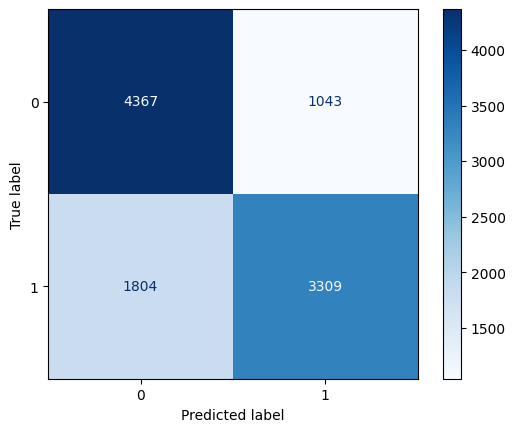

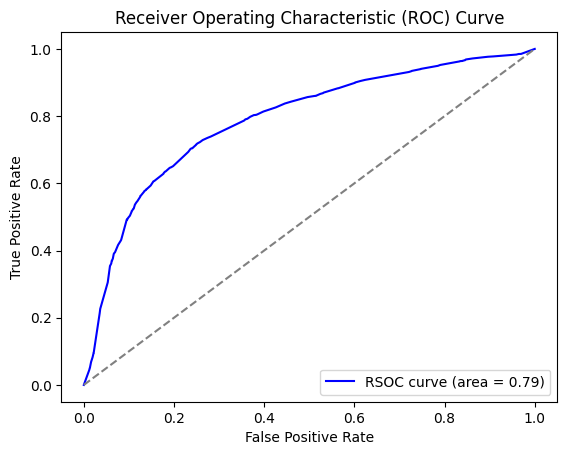

In [ ]:
#import decision tree classifier
from sklearn.tree import DecisionTreeClassifier

decisiontree_model = DecisionTreeClassifier(max_depth=10, min_samples_leaf=1, min_samples_split=5, random_state=42, criterion='entropy')        
decisiontree_model.fit(X_train, y_train.values.ravel())

y_pred = decisiontree_model.predict(X_test)

# Evaluate the model
print("Training Accuracy:", accuracy_score(y_train, decisiontree_model.predict(X_train))) # Training accuracy
print("Testing Accuracy:", f"{accuracy_score(y_test, y_pred):.3f}") # Testing accuracy
print("Recall:", f"{recall_score(y_test, y_pred):.3f}")
print("Precision:", f"{precision_score(y_test, y_pred):.3f}")
print("F1 Score:", f"{f1_score(y_test, y_pred):.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(cmap=plt.cm.Blues)

# Calculate probabilities and ROC curve
y_prob = decisiontree_model.predict_proba(X_test)[:, 1] # Get probabilities for the positive class
fp, tp, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
print(f"AUC Score: {roc_auc:.3f}")

# Plot ROC curve
plt.figure()
plt.plot(fp, tp, color='blue', label=f'RSOC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


## 2. K-NN

Training Accuracy: 0.765679939180842
Testing Accuracy: 0.706
Recall: 0.686
Precision: 0.702
F1 Score: 0.694

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.72      0.72      5410
           1       0.70      0.69      0.69      5113

    accuracy                           0.71     10523
   macro avg       0.71      0.71      0.71     10523
weighted avg       0.71      0.71      0.71     10523

AUC Score: 0.762


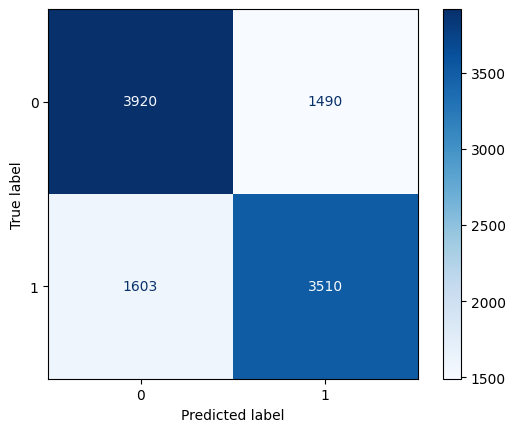

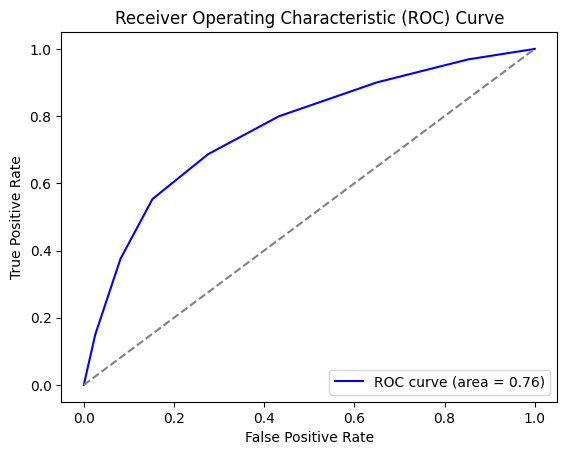

In [9]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNN classifier
knn_model = KNeighborsClassifier(n_neighbors=7, metric='manhattan', weights='uniform')

# Train the model
knn_model.fit(X_train, y_train.values.ravel())

# Make predictions
y_pred = knn_model.predict(X_test)

# Evaluate the model
print("Training Accuracy:", accuracy_score(y_train, knn_model.predict(X_train))) # Training accuracy
print("Testing Accuracy:", f"{accuracy_score(y_test, y_pred):.3f}") # Testing accuracy
print("Recall:", f"{recall_score(y_test, y_pred):.3f}")
print("Precision:", f"{precision_score(y_test, y_pred):.3f}")
print("F1 Score:", f"{f1_score(y_test, y_pred):.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(cmap=plt.cm.Blues)

# Calculate probabilities and ROC curve
y_prob = knn_model.predict_proba(X_test)[:, 1] # Get probabilities for the positive class
fp, tp, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
print(f"AUC Score: {roc_auc:.3f}")

# Plot ROC curve
plt.figure()
plt.plot(fp, tp, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

## 3. Perceptron

Training Accuracy: 0.6761142259811841
Testing Accuracy: 0.687
Recall: 0.754
Precision: 0.655
F1 Score: 0.701

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.62      0.67      5410
           1       0.65      0.75      0.70      5113

    accuracy                           0.69     10523
   macro avg       0.69      0.69      0.69     10523
weighted avg       0.69      0.69      0.69     10523

AUC Score: 0.756


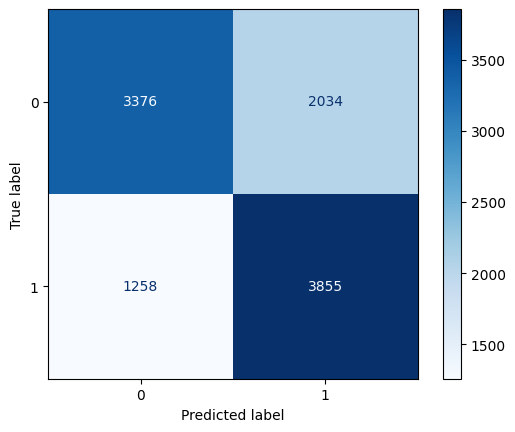

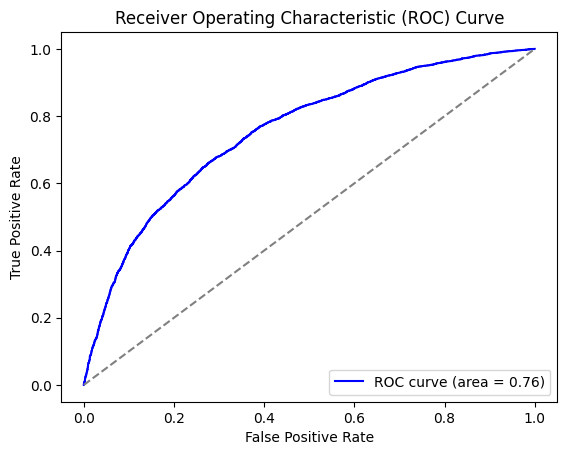

In [10]:
from sklearn.linear_model import Perceptron

perceptron_model = Perceptron(alpha=0.1, max_iter=5000, random_state=42)
perceptron_model.fit(X_train, y_train.values.ravel())

y_pred = perceptron_model.predict(X_test)

# Evaluate the model
print("Training Accuracy:", accuracy_score(y_train, perceptron_model.predict(X_train))) # Training accuracy
print("Testing Accuracy:", f"{accuracy_score(y_test, y_pred):.3f}") # Testing accuracy
print("Recall:", f"{recall_score(y_test, y_pred):.3f}")
print("Precision:", f"{precision_score(y_test, y_pred):.3f}")
print("F1 Score:", f"{f1_score(y_test, y_pred):.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(cmap=plt.cm.Blues)

# Calculate probabilities and ROC curve
y_prob = perceptron_model.decision_function(X_test)
fp, tp, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
print(f"AUC Score: {roc_auc:.3f}")

# Plot ROC curve
plt.figure()
plt.plot(fp, tp, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

## 4. MultiLayer-Perceptron

Training Accuracy: 0.7358167822864202
Testing Accuracy: 0.739
Recall: 0.700
Precision: 0.747
F1 Score: 0.723

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.78      0.75      5410
           1       0.75      0.70      0.72      5113

    accuracy                           0.74     10523
   macro avg       0.74      0.74      0.74     10523
weighted avg       0.74      0.74      0.74     10523



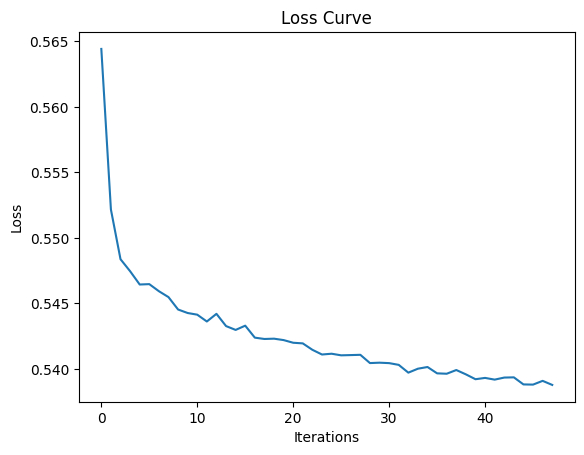

AUC Score: 0.805


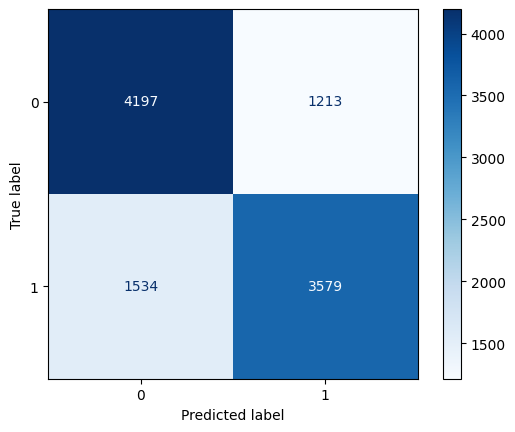

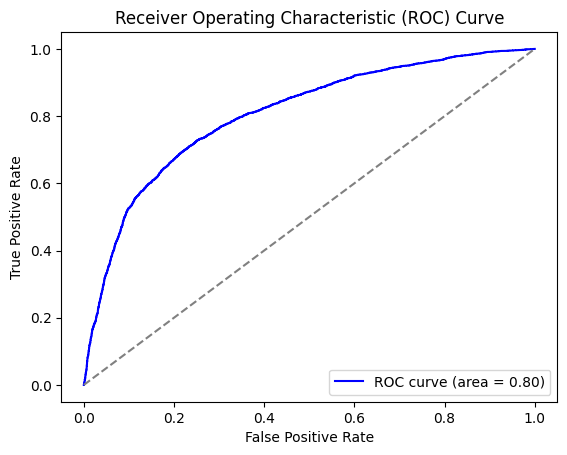

In [11]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(hidden_layer_sizes=(50, 50), max_iter=5000, activation='relu', solver='adam', early_stopping=True, learning_rate='adaptive', random_state=42)
mlp_model.fit(X_train, y_train.values.ravel())

y_pred = mlp_model.predict(X_test)

# Evaluate the model
print("Training Accuracy:", accuracy_score(y_train, mlp_model.predict(X_train))) # Training accuracy
print("Testing Accuracy:", f"{accuracy_score(y_test, y_pred):.3f}") # Testing accuracy
print("Recall:", f"{recall_score(y_test, y_pred):.3f}")
print("Precision:", f"{precision_score(y_test, y_pred):.3f}")
print("F1 Score:", f"{f1_score(y_test, y_pred):.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

#loss curve
plt.figure()
plt.plot(mlp_model.loss_curve_)
plt.title('Loss Curve')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.show()

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(cmap=plt.cm.Blues)

# Calculate probabilities and ROC curve
y_prob = mlp_model.predict_proba(X_test)[:, 1]
fp, tp, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
print(f"AUC Score: {roc_auc:.3f}")

# Plot ROC curve
plt.figure()
plt.plot(fp, tp, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

## 5. SVM

Training Accuracy: 0.7312315879502043
Testing Accuracy: 0.738
Recall: 0.675
Precision: 0.759
F1 Score: 0.715

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.80      0.76      5410
           1       0.76      0.67      0.71      5113

    accuracy                           0.74     10523
   macro avg       0.74      0.74      0.74     10523
weighted avg       0.74      0.74      0.74     10523

AUC Score: 0.797


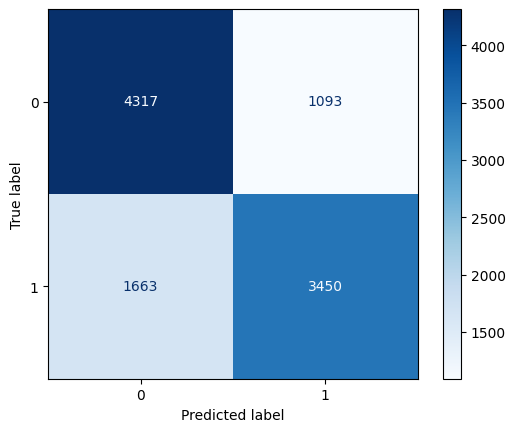

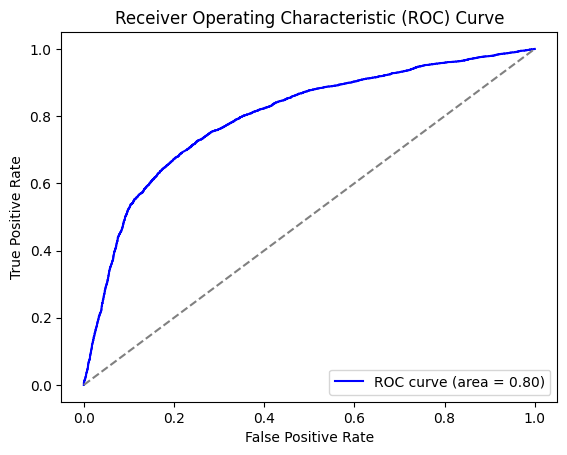

In [12]:
from sklearn.svm import SVC

# Initialize the SVM classifier
svm_model = SVC(C=1, gamma="scale", probability=True, random_state=42, class_weight='balanced')

# Train the model
svm_model.fit(X_train, y_train.values.ravel())

# Make predictions
y_pred = svm_model.predict(X_test)

# Evaluate the model
print("Training Accuracy:", accuracy_score(y_train, svm_model.predict(X_train))) # Training accuracy
print("Testing Accuracy:", f"{accuracy_score(y_test, y_pred):.3f}") # Testing accuracy
print("Recall:", f"{recall_score(y_test, y_pred):.3f}")
print("Precision:", f"{precision_score(y_test, y_pred):.3f}")
print("F1 Score:", f"{f1_score(y_test, y_pred):.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(cmap=plt.cm.Blues)

# Calculate probabilities and ROC curve
y_prob = svm_model.predict_proba(X_test)[:, 1]
fp, tp, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
print(f"AUC Score: {roc_auc:.3f}")

# Plot ROC curve
plt.figure()
plt.plot(fp, tp, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

## 6. Random Forest

Training Accuracy: 0.963128385441414
Testing Accuracy: 0.721
Recall: 0.694
Precision: 0.720
F1 Score: 0.707

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.75      0.73      5410
           1       0.72      0.69      0.71      5113

    accuracy                           0.72     10523
   macro avg       0.72      0.72      0.72     10523
weighted avg       0.72      0.72      0.72     10523

AUC Score: 0.782


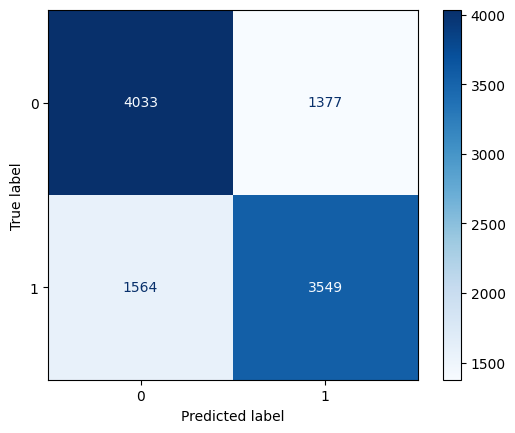

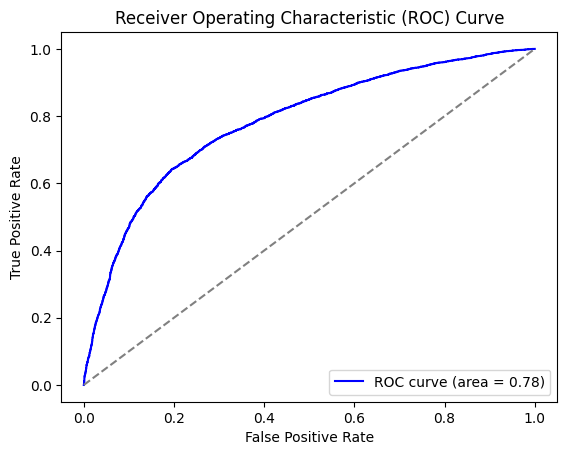

In [13]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest classifier
rf_model = RandomForestClassifier(max_depth= None, max_features= 'sqrt', min_samples_split=5, n_estimators=200, random_state=42)

# Train the model
rf_model.fit(X_train, y_train.values.ravel())

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("Training Accuracy:", accuracy_score(y_train, rf_model.predict(X_train))) # Training accuracy
print("Testing Accuracy:", f"{accuracy_score(y_test, y_pred):.3f}") # Testing accuracy
print("Recall:", f"{recall_score(y_test, y_pred):.3f}")
print("Precision:", f"{precision_score(y_test, y_pred):.3f}")
print("F1 Score:", f"{f1_score(y_test, y_pred):.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(cmap=plt.cm.Blues)

# Calculate probabilities and ROC curve
y_prob = rf_model.predict_proba(X_test)[:, 1]
fp, tp, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
print(f"AUC Score: {roc_auc:.3f}")

# Plot ROC curve
plt.figure()
plt.plot(fp, tp, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()